Loaded 12343 records from 7 models across 3 rounds
Models: ['DeleteHit2Lead(CrossDock)', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD_cond_crossdocked', 'diffSBDD_cond_moad', 'shepherd_x1x3x4_mosesaq_submission']
Rounds: ['Round1', 'Round2', 'Round3']
Columns: ['uniprot', 'series', 'has_smiles_hit', 'smiles_hit_num', 'smiles_hit_rate', 'smiles_hit_fraction', 'has_scaffold_hit', 'scaffold_hit_rate', 'scaffold_hit_fraction', 'normalized_affinity_sum', 'ModelName', 'Round', 'uniprot_series']

Seen proteins - unique uniprot_series: 2913
Unseen proteins - unique uniprot_series: 1206


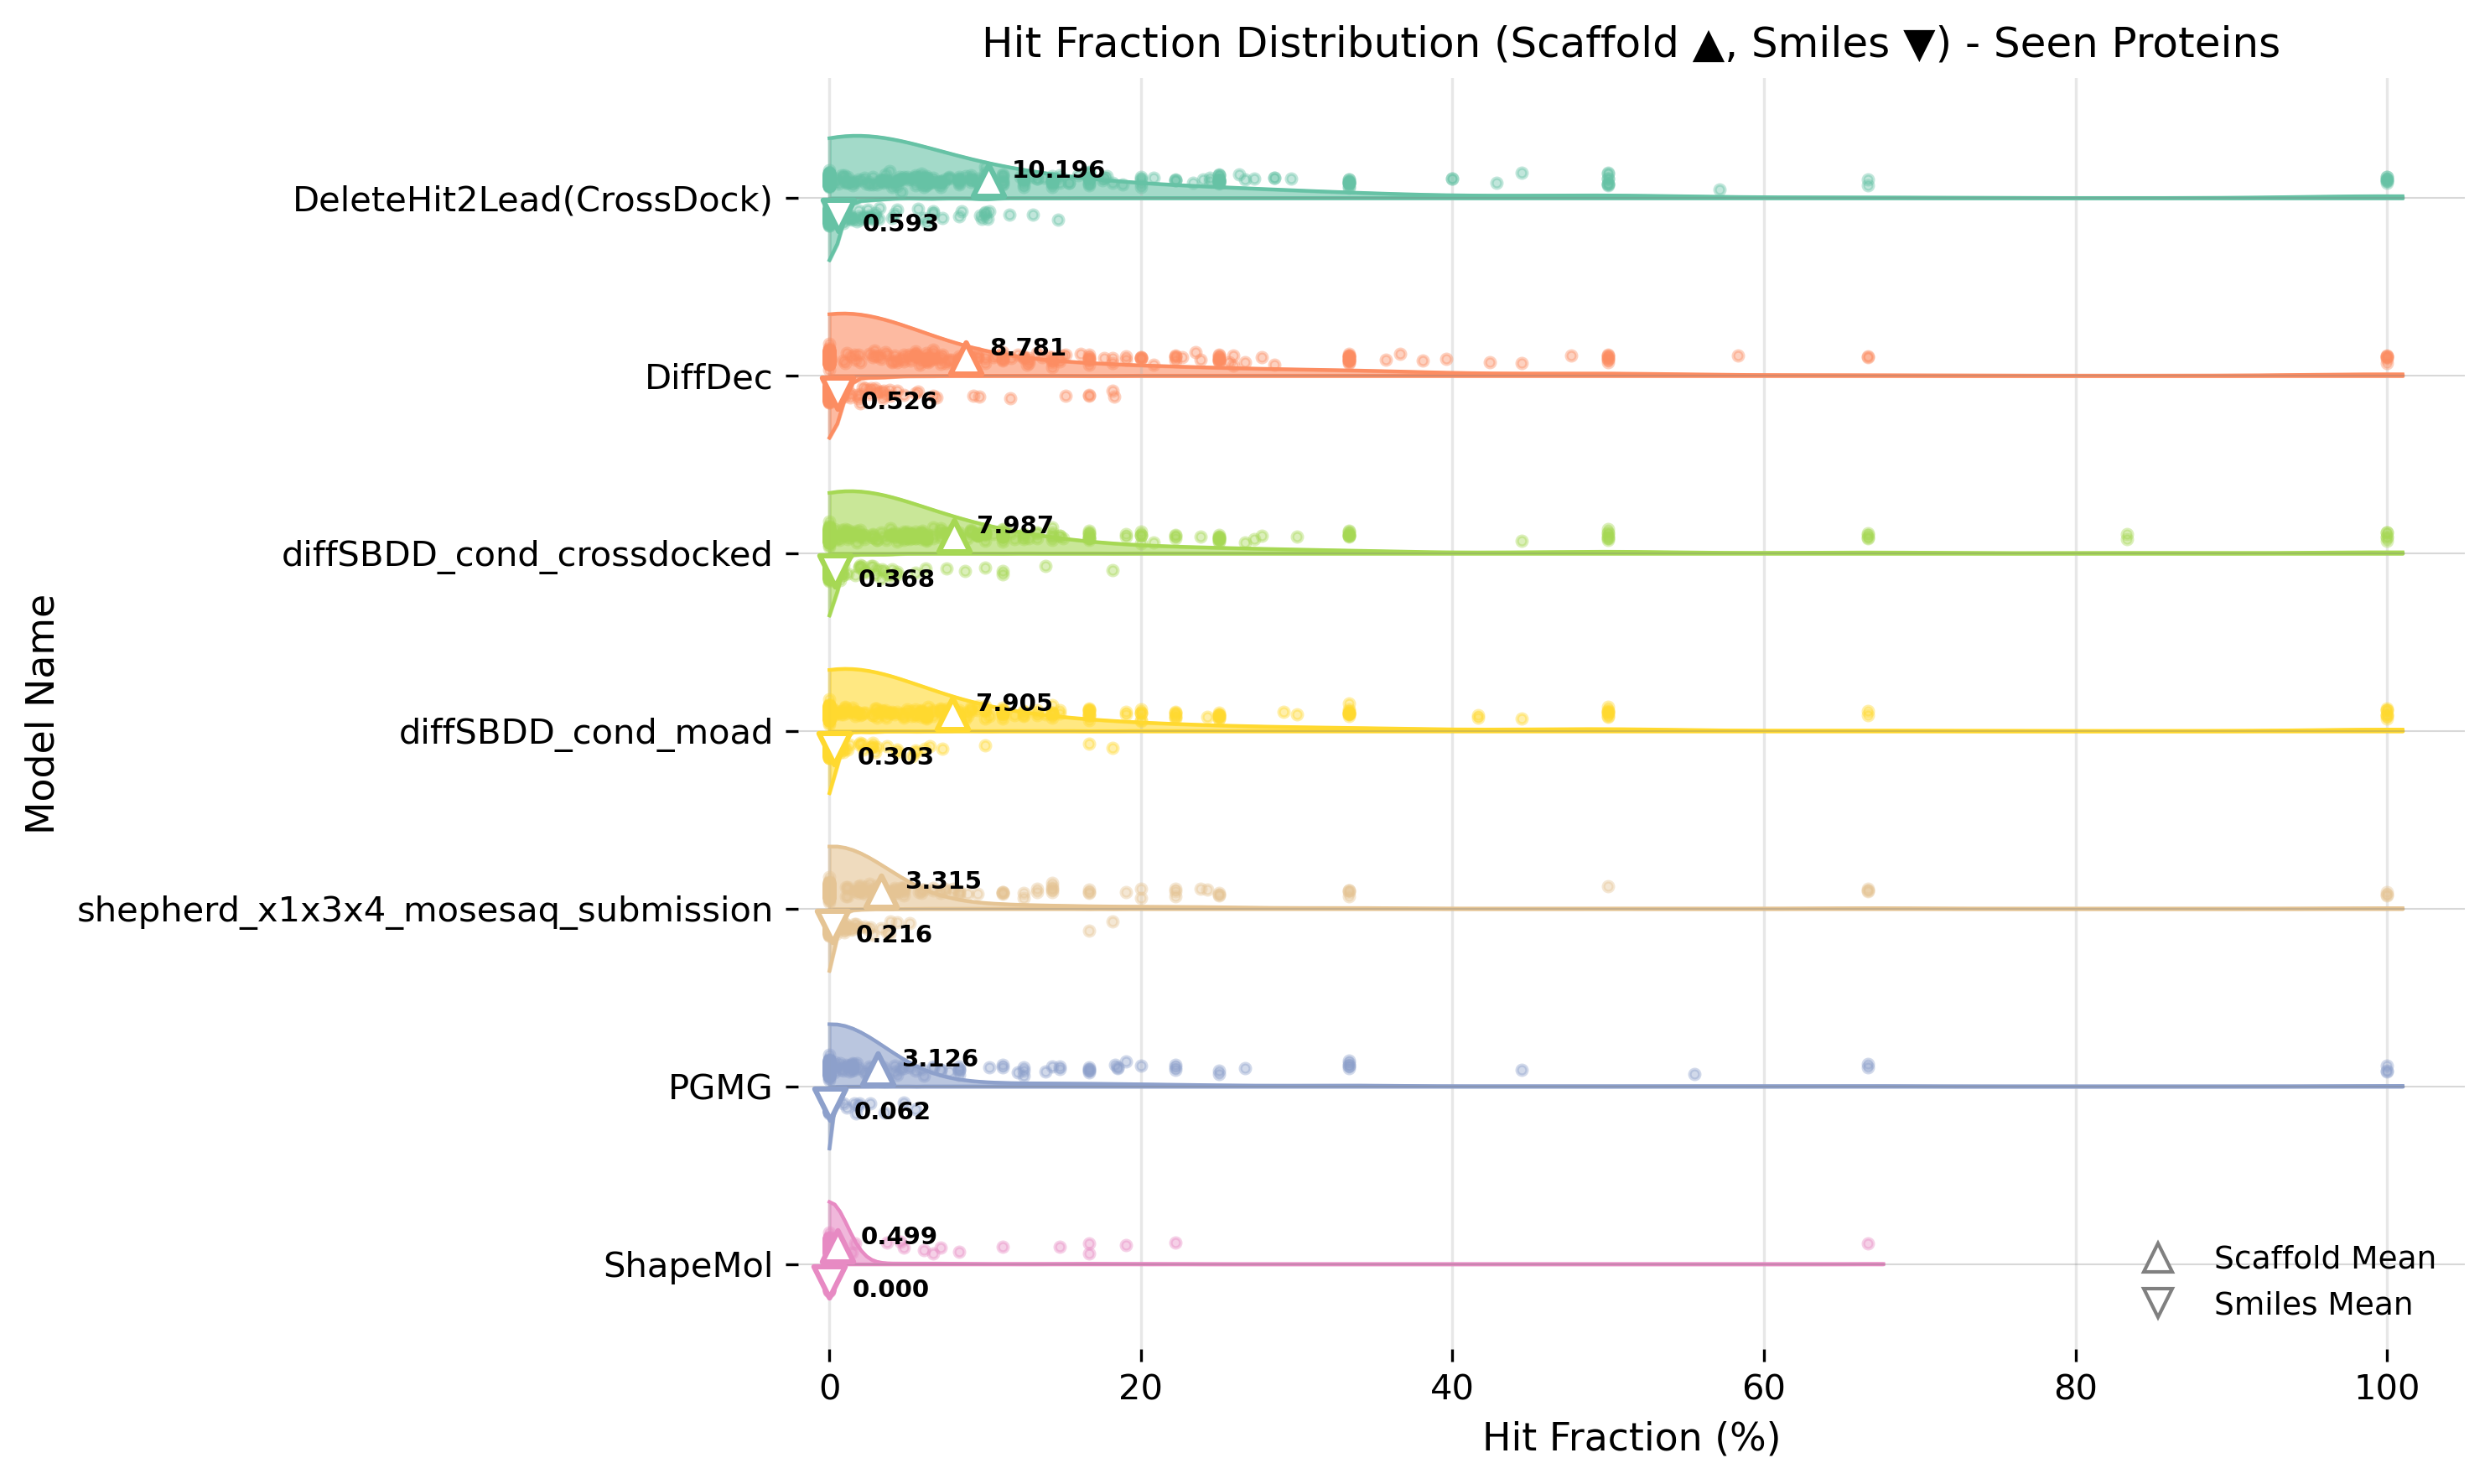

✓ Saved: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/hit_fraction_h2l/hit2lead_hit_fraction_seen_protein.svg


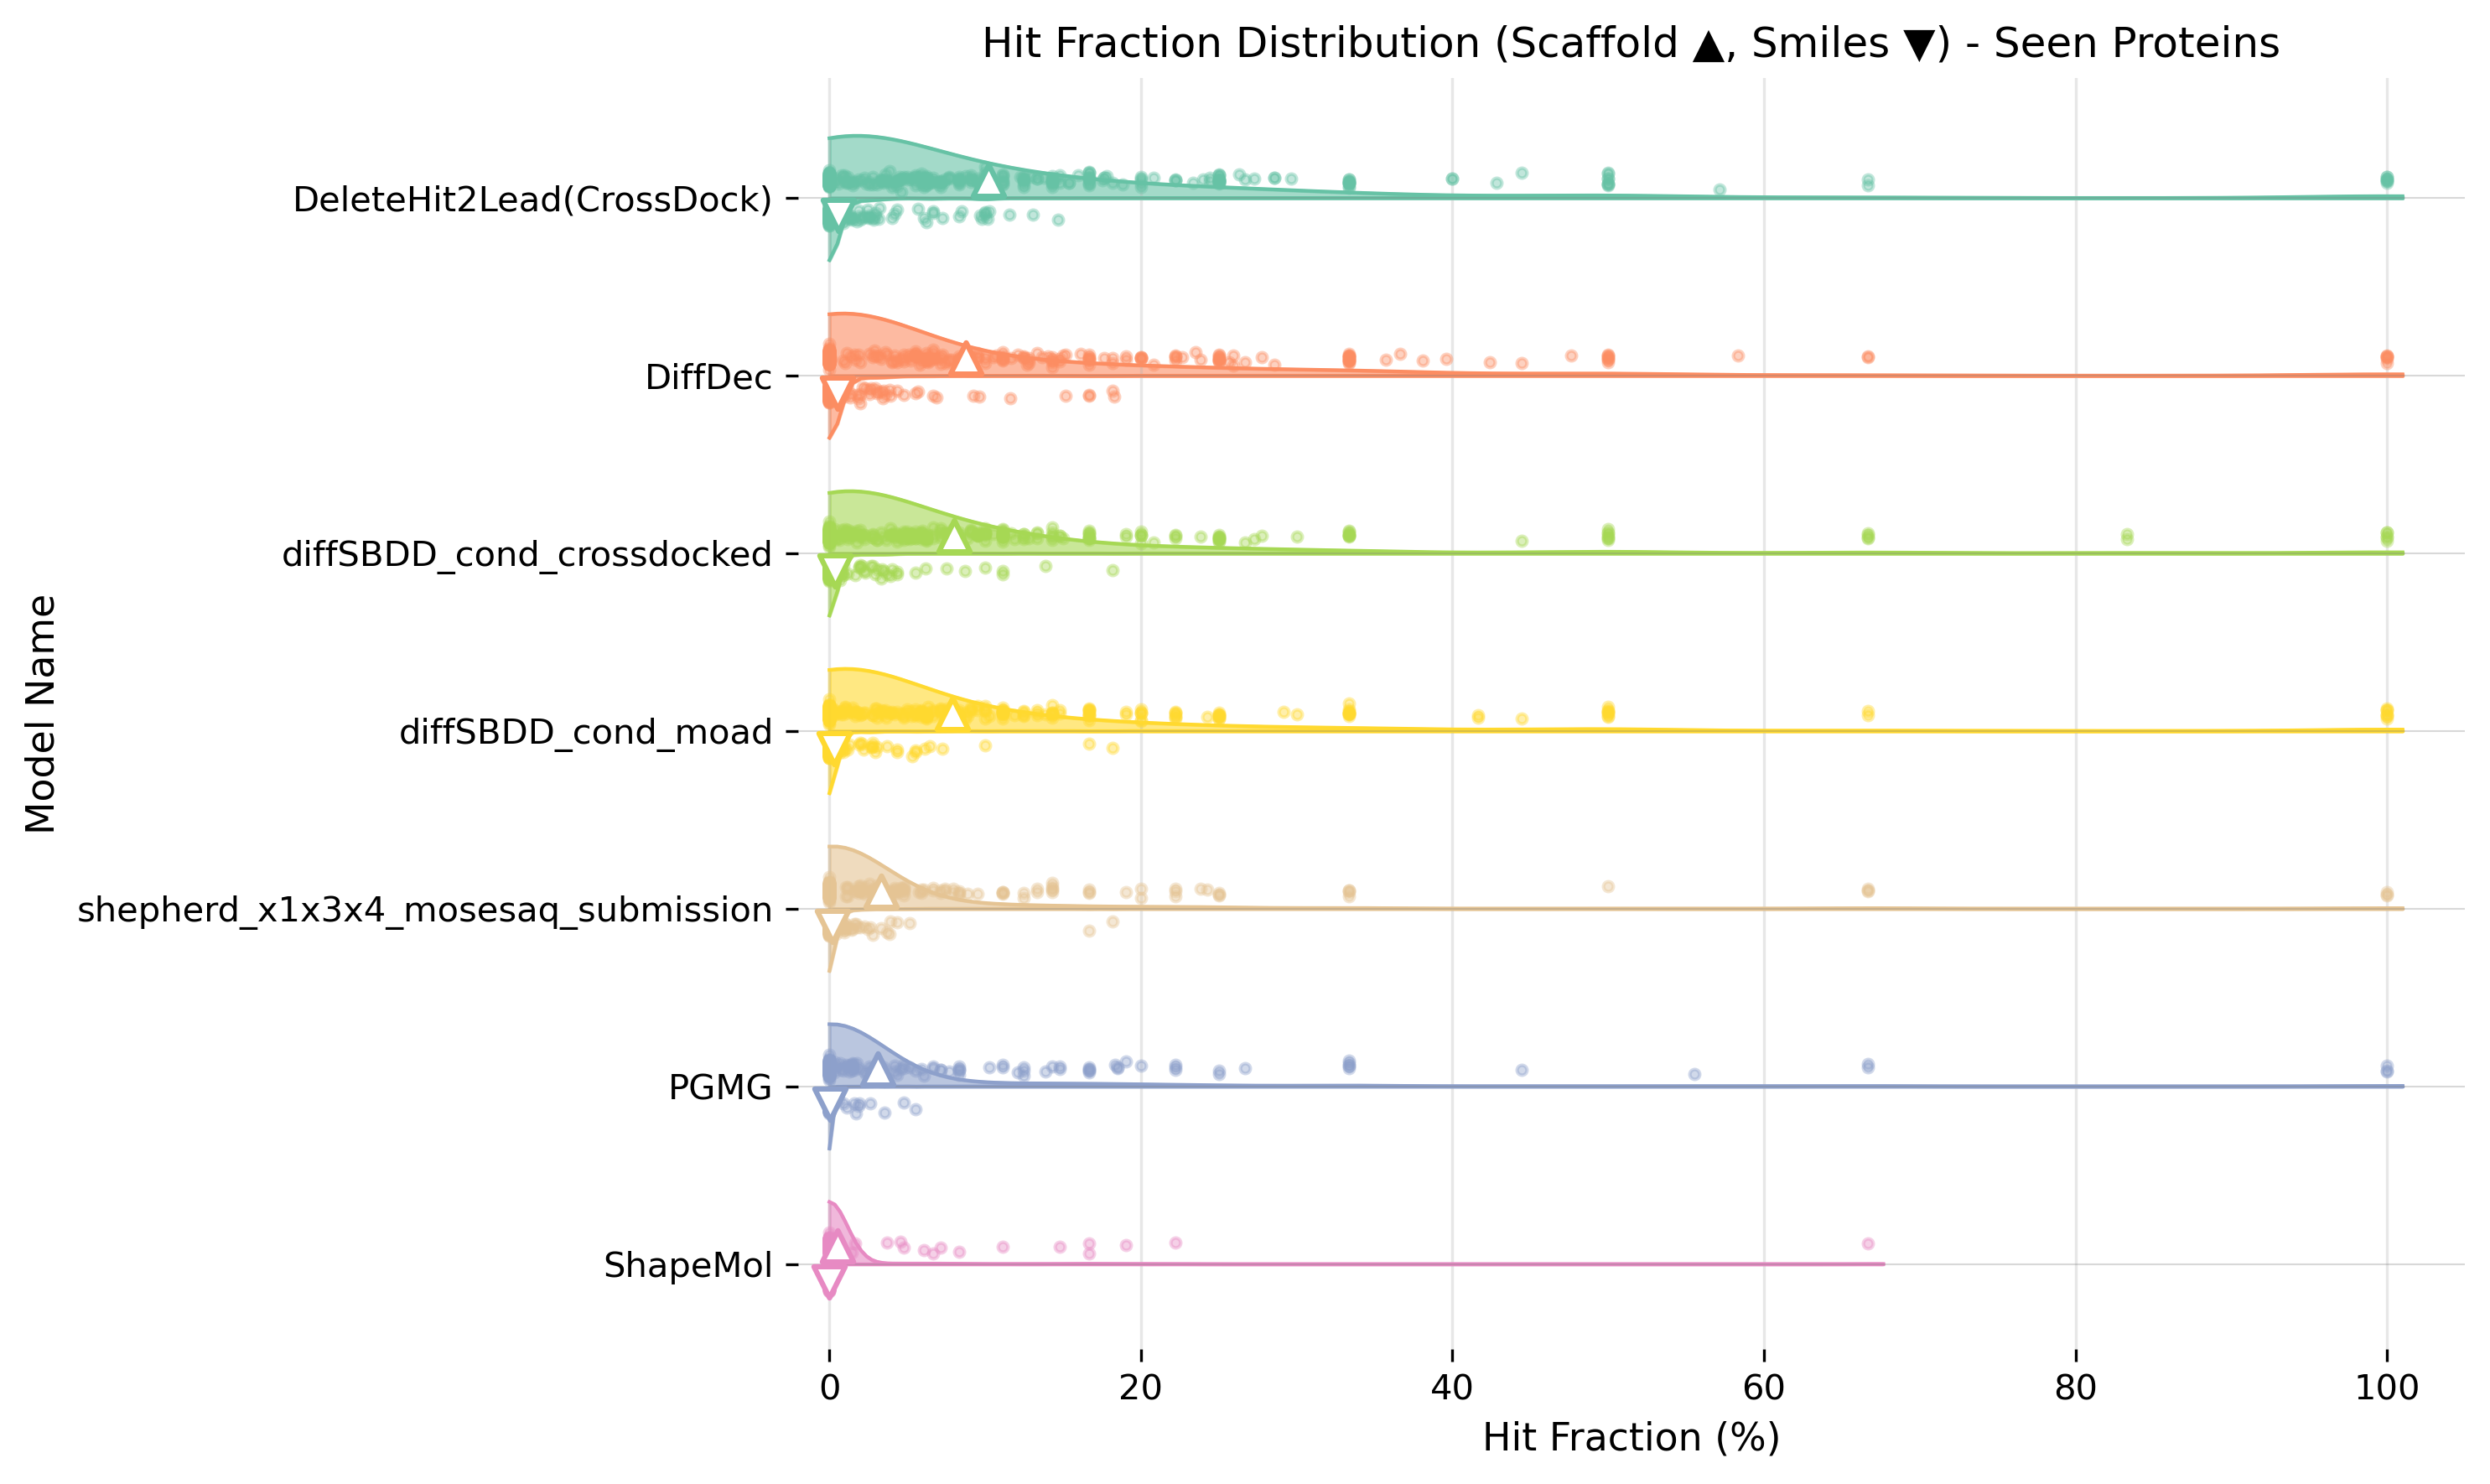

✓ Saved: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/hit_fraction_h2l/hit2lead_hit_fraction_seen_protein_no_text.svg


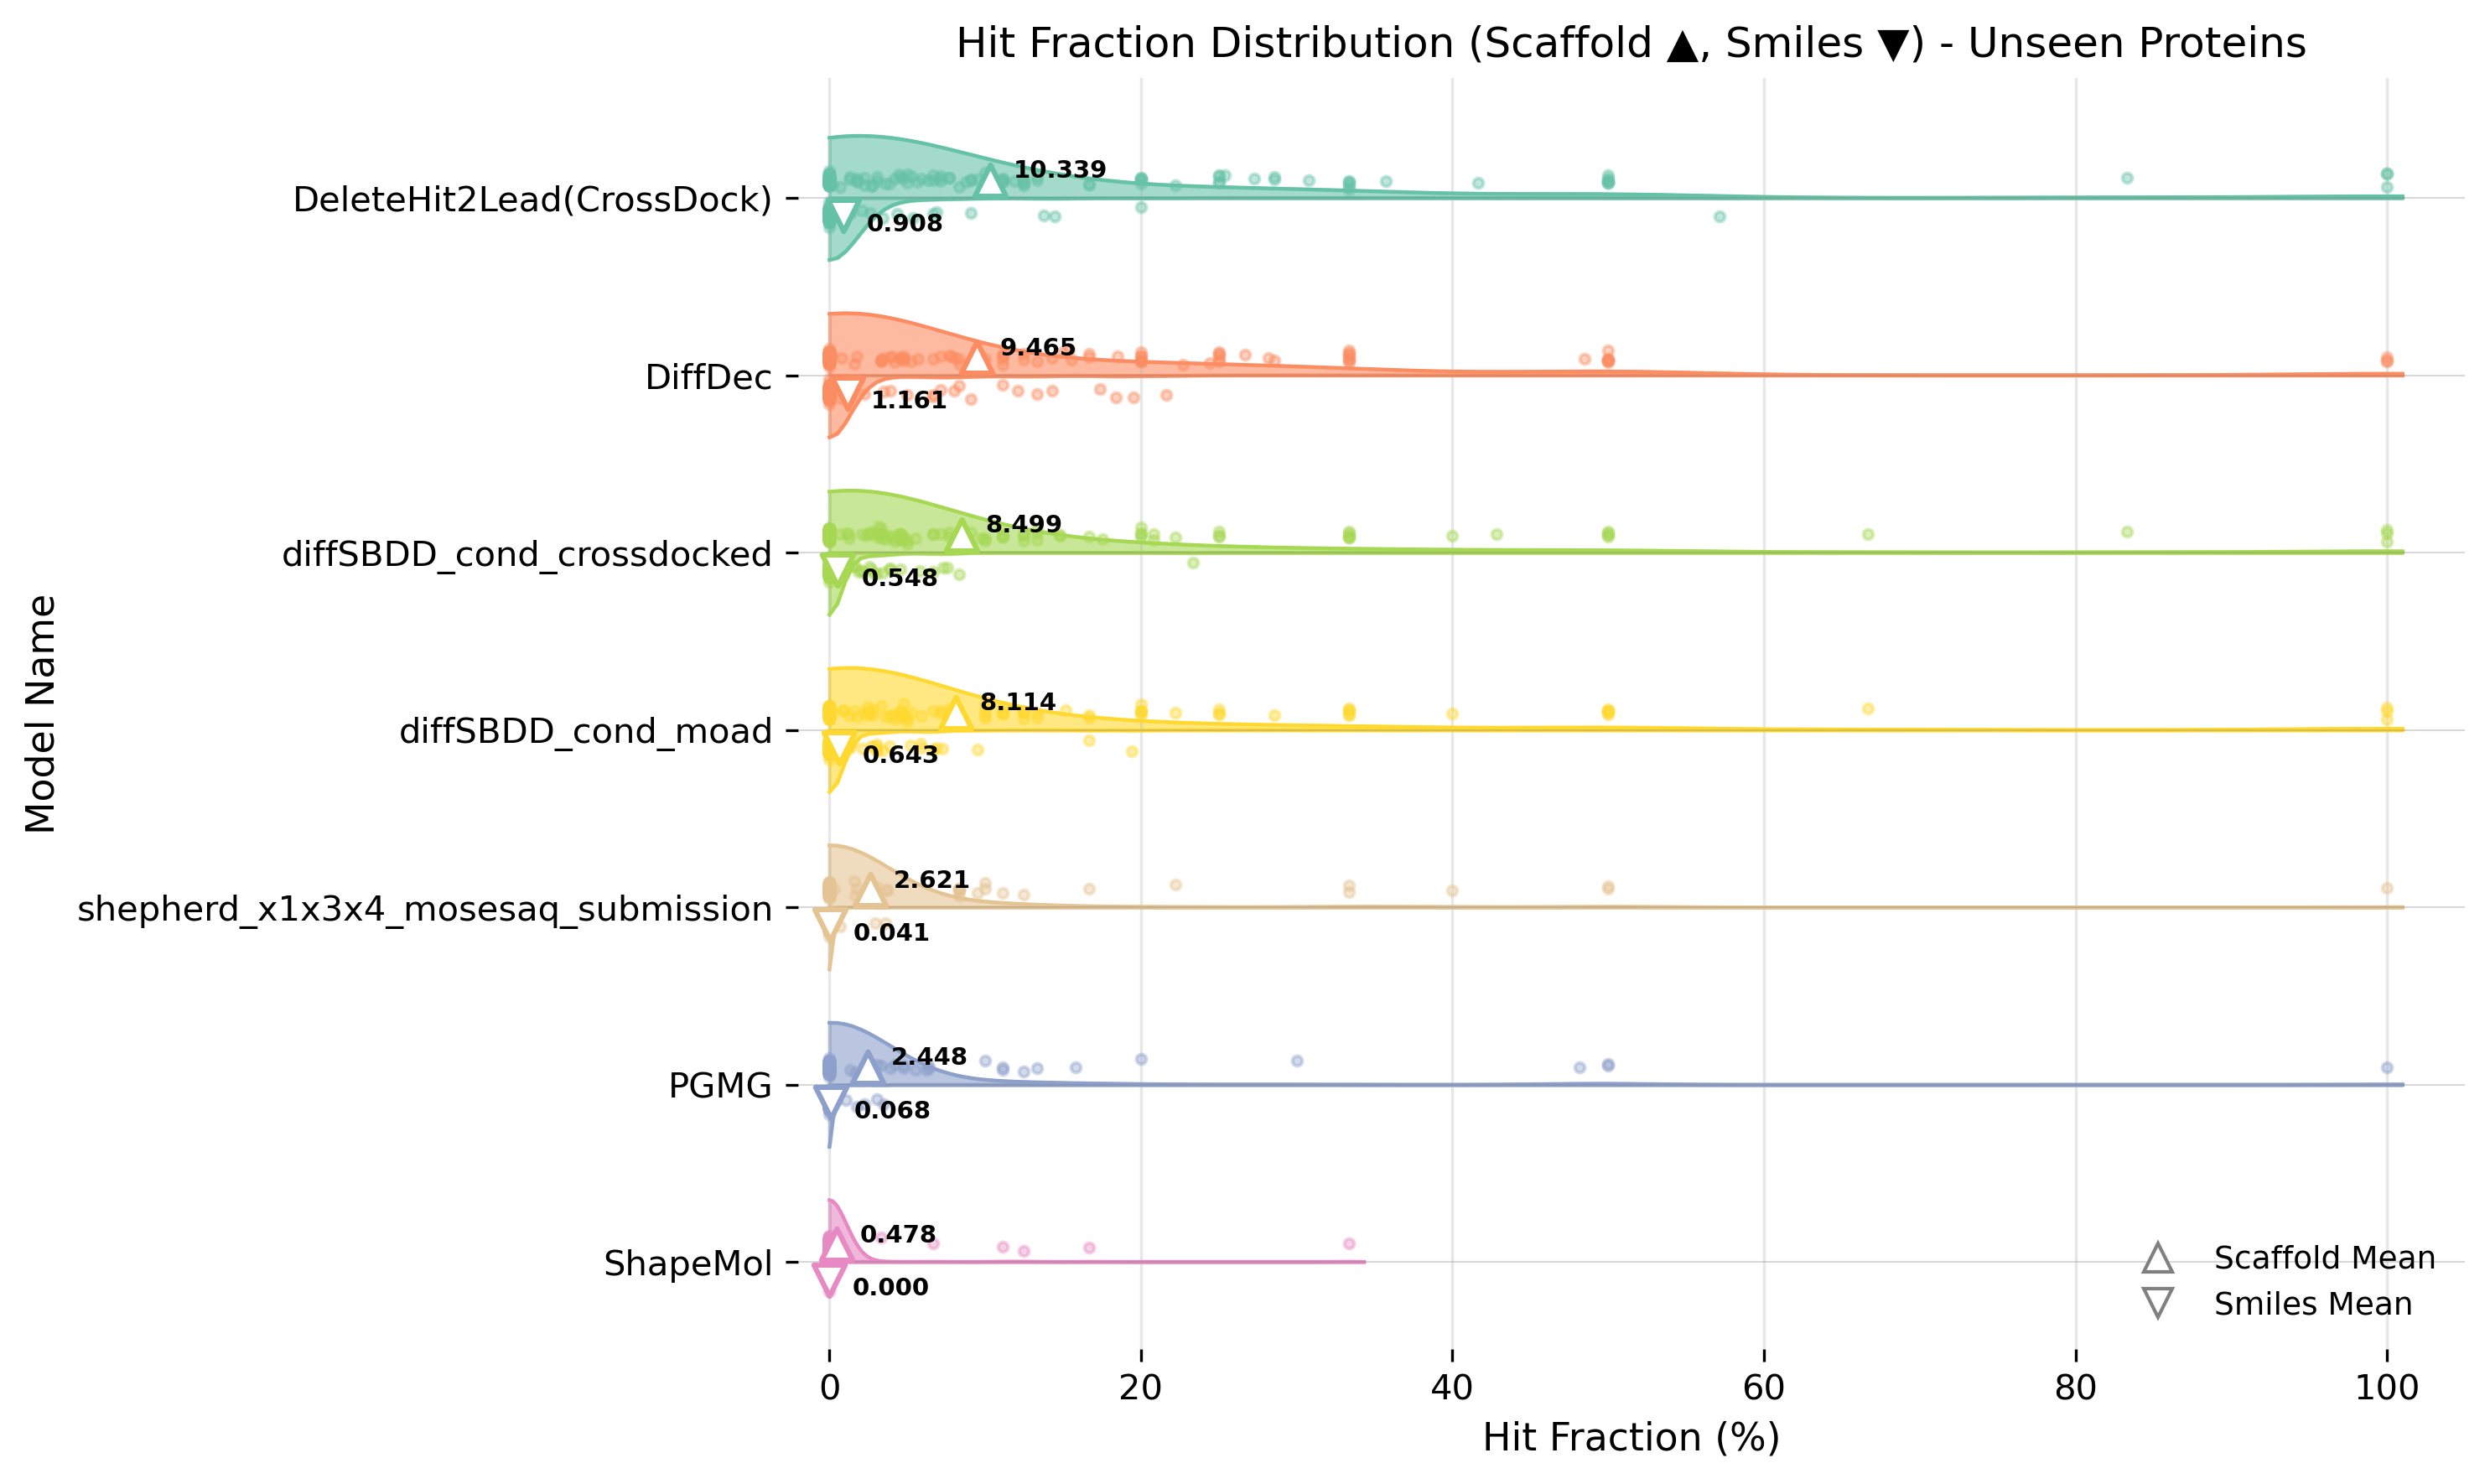

✓ Saved: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/hit_fraction_h2l/hit2lead_hit_fraction_unseen_protein.svg


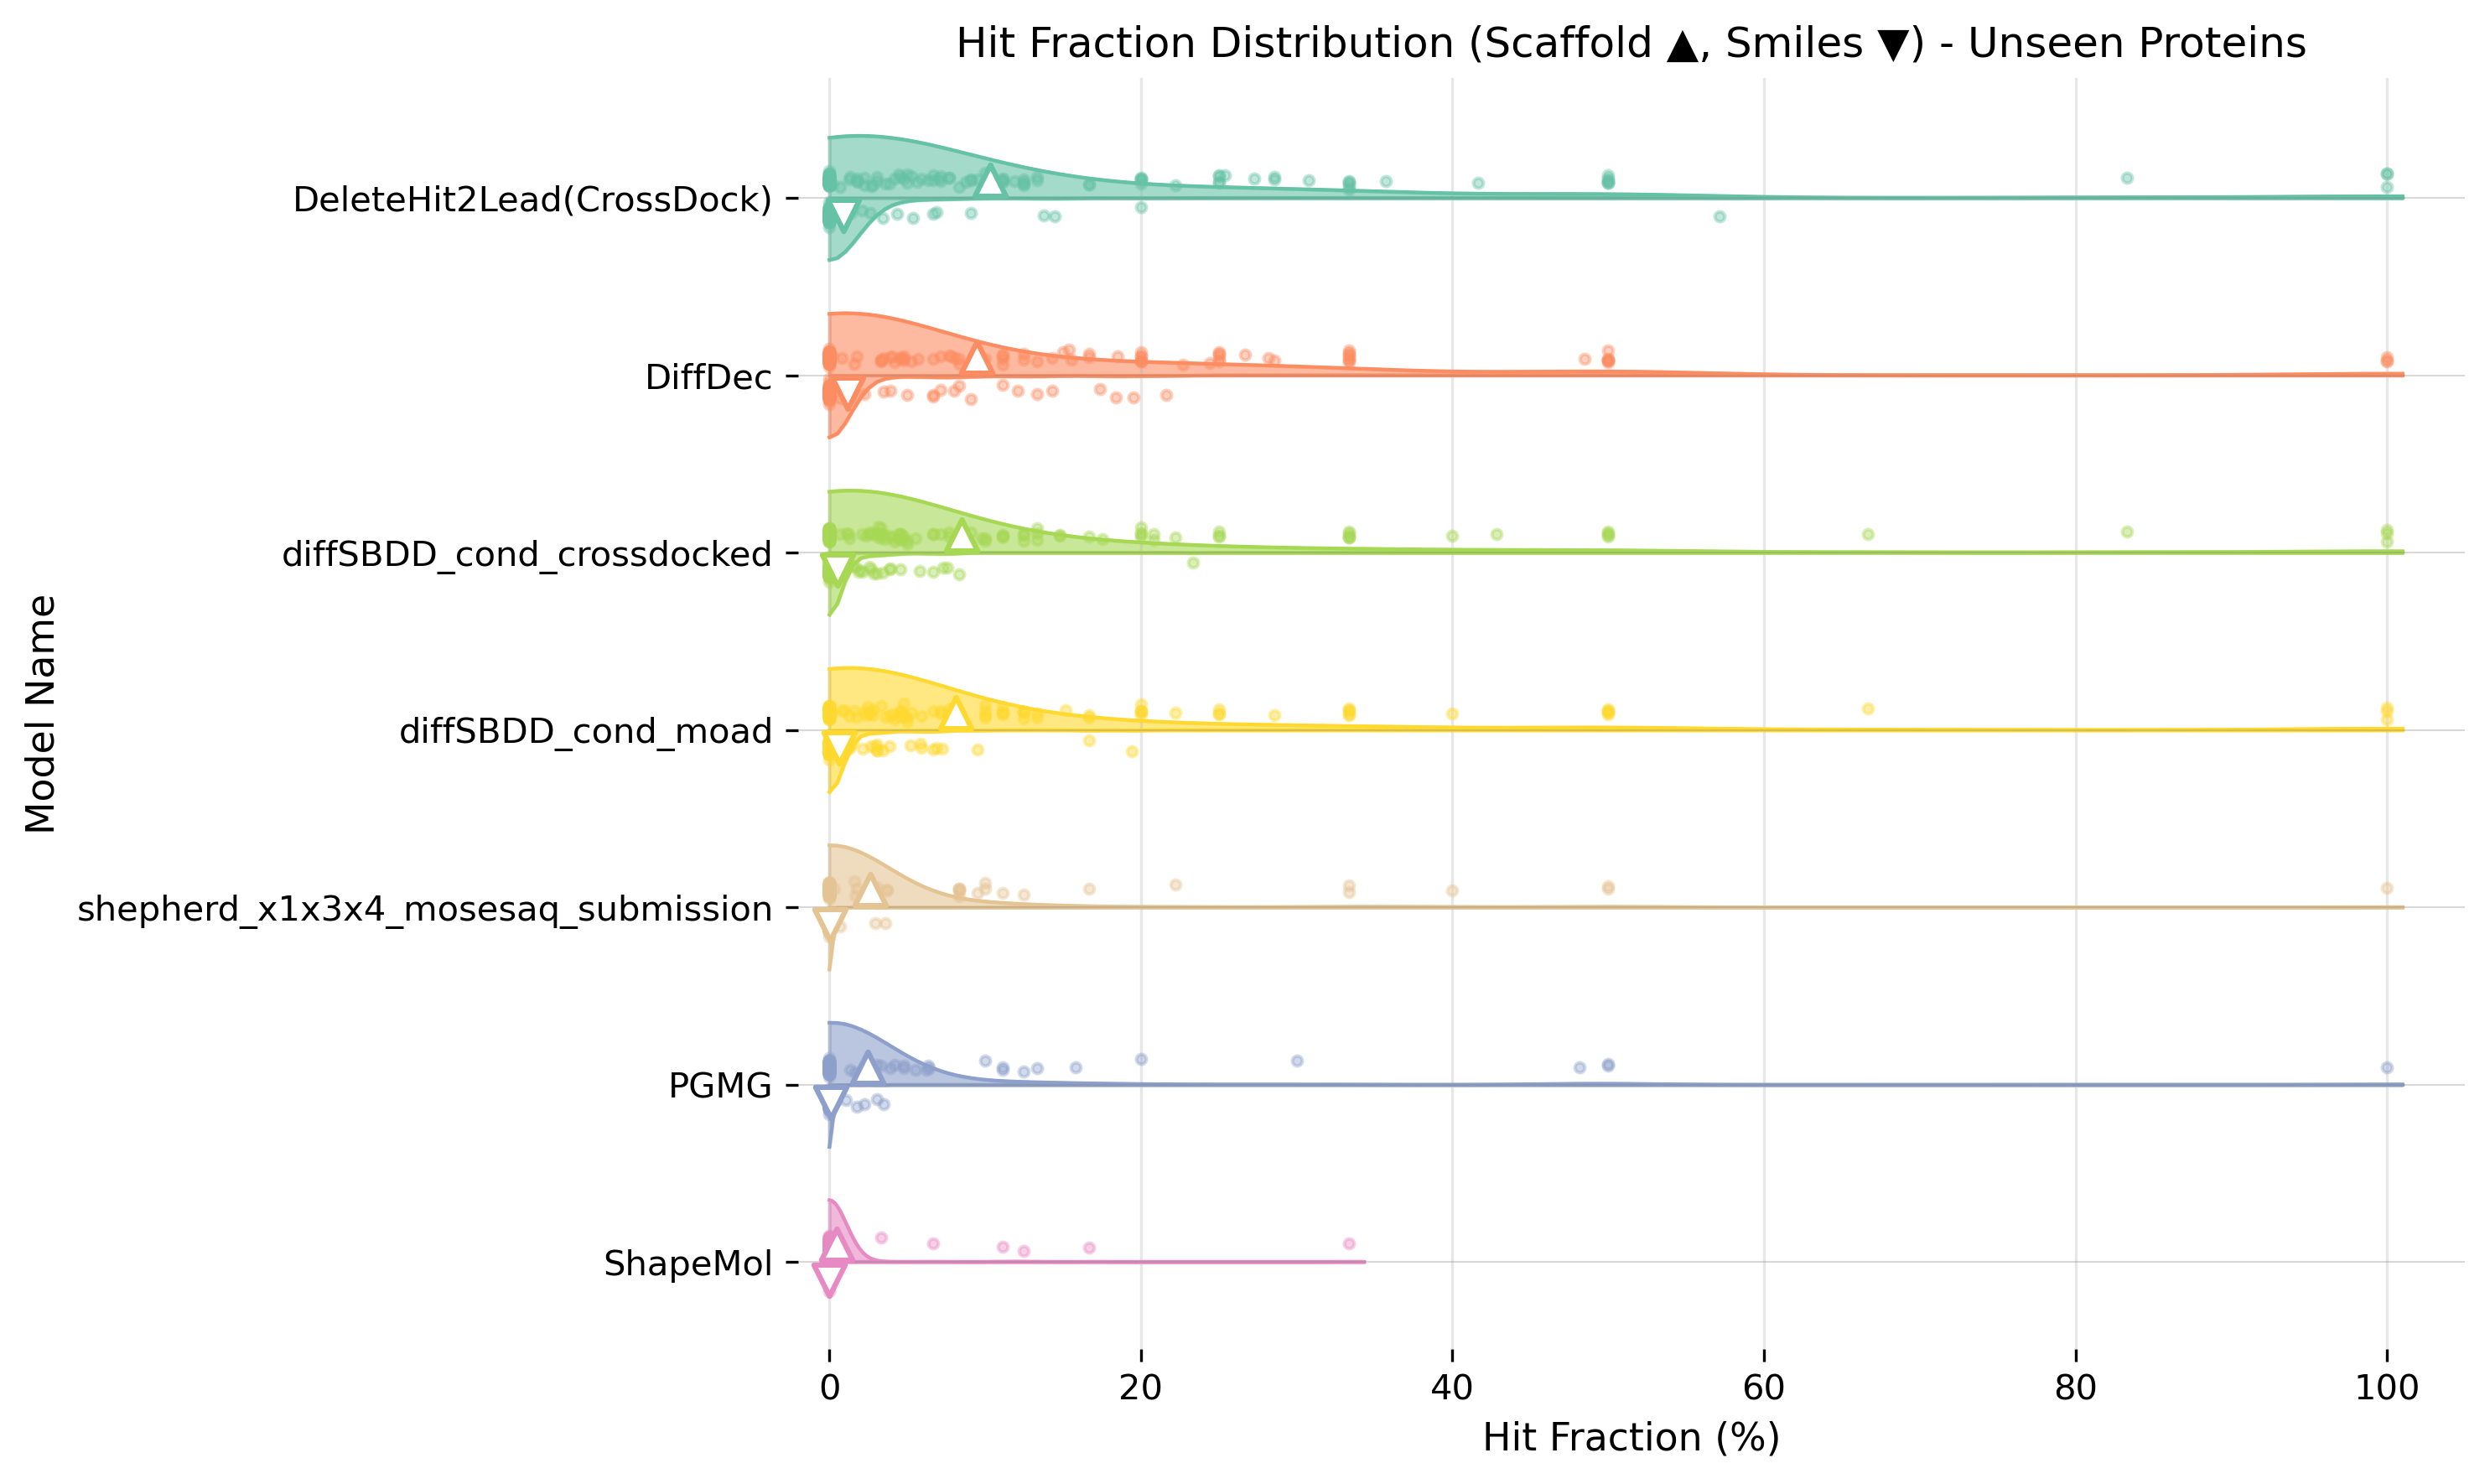

✓ Saved: /home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow_new/final_plot/output/hit_fraction_h2l/hit2lead_hit_fraction_unseen_protein_no_text.svg

All H2L hit fraction plots generated successfully!


In [ ]:
import os
import sys
code_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/"
sys.path.append(code_path)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sup_info.utils import uniprot_in_trainset

# ==================== 配置部分 ====================
TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

NAME_MAP = {
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "DeleteHit2Lead(CrossDock)",
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "diffSBDD_cond_crossdocked",
    "diffSBDD_cond_moad_Hit_to_Lead": "diffSBDD_cond_moad",
    "PGMG_Hit_to_Lead": "PGMG",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "shepherd_x1x3x4_mosesaq_submission",
}

# 3个Round的路径
ROUND_LIST = ["Round1", "Round2", "Round3"]
base_results_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
output_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow/final_plot/output/hit_fraction_h2l"

# 确保输出目录存在
os.makedirs(output_path, exist_ok=True)


# ==================== 数据读取（3个Round） ====================
results_df = []
for round_name in ROUND_LIST:
    for task in TASK_LIST_H2L:
        file = os.path.join(base_results_path, round_name, "Hit_to_Lead_Results", task, "hitrediscovery_detail.csv")
        if os.path.exists(file):
            df = pd.read_csv(file)
            df["ModelName"] = NAME_MAP[task]
            df["Round"] = round_name
            results_df.append(df)
        else:
            print(f"Warning: File not found - {file}")

result_df = pd.concat(results_df, ignore_index=True)
result_df["uniprot_series"] = result_df["uniprot"] + "_" + result_df["series"]

# 创建颜色映射（使用 Set2 配色）
model_names = sorted(result_df["ModelName"].unique())
color_list = sns.color_palette("Set2", n_colors=len(model_names))
color_map = {name: color_list[i] for i, name in enumerate(model_names)}

print(f"Loaded {len(result_df)} records from {len(model_names)} models across {len(ROUND_LIST)} rounds")
print(f"Models: {model_names}")
print(f"Rounds: {result_df['Round'].unique().tolist()}")
print(f"Columns: {result_df.columns.tolist()}")

# ==================== 数据聚合（按 ModelName 和 uniprot_series 平均，跨3个Round） ====================
data_mean_from_uniprot = result_df.groupby(['ModelName', 'uniprot_series']).agg({
    'scaffold_hit_fraction': 'mean',  # 改为 scaffold_hit_fraction
    'smiles_hit_fraction': 'mean'     # 改为 smiles_hit_fraction
})

# ==================== 数据分割与绘图 ====================
# 分割 seen 和 unseen 蛋白（基于 uniprot 列）
result_df['is_seen'] = result_df['uniprot'].isin(uniprot_in_trainset)

data_seen = result_df[result_df['is_seen']]
data_unseen = result_df[~result_df['is_seen']]

# 聚合 seen 数据（跨3个Round平均）
data_mean_seen = data_seen.groupby(['ModelName', 'uniprot_series']).agg({
    'scaffold_hit_fraction': 'mean',  # 改为 scaffold_hit_fraction
    'smiles_hit_fraction': 'mean'     # 改为 smiles_hit_fraction
})

# 聚合 unseen 数据（跨3个Round平均）
data_mean_unseen = data_unseen.groupby(['ModelName', 'uniprot_series']).agg({
    'scaffold_hit_fraction': 'mean',  # 改为 scaffold_hit_fraction
    'smiles_hit_fraction': 'mean'     # 改为 smiles_hit_fraction
})

print(f"\nSeen proteins - unique uniprot_series: {len(data_mean_seen)}")
print(f"Unseen proteins - unique uniprot_series: {len(data_mean_unseen)}")


# ==================== 绘图函数 ====================
def create_ridge_plot(data_mean, title_suffix, save_filename, color_map, show_mean_text=True):
    """
    Create ridge plot for given data subset.
    """
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # Get model order by mean scaffold hit fraction
    data_plot = data_mean.reset_index()
    model_order = data_plot.groupby('ModelName')['scaffold_hit_fraction'].mean().sort_values(ascending=True).index.tolist()
    
    # Prepare data for ridge plot
    ridge_spacing = 1.0
    y_positions = np.arange(len(model_order)) * ridge_spacing
    
    # 获取数据并乘以100转换为百分比
    scaffold_data = []
    smiles_data = []
    for model in model_order:
        if model in data_mean.index.get_level_values(0):
            scaffold_data.append(data_mean.loc[model]['scaffold_hit_fraction'].values * 100)
            smiles_data.append(data_mean.loc[model]['smiles_hit_fraction'].values * 100)
        else:
            scaffold_data.append(np.array([0]))
            smiles_data.append(np.array([0]))
    
    # Create ridge plot
    for i, model in enumerate(model_order):
        y_base = y_positions[i]
        scaffold_values = scaffold_data[i]
        smiles_values = smiles_data[i]
        
        # Calculate common x_range
        all_vals = np.concatenate([scaffold_values, smiles_values])
        x_min = max(0, all_vals.min() - 1)
        x_max_val = all_vals.max() + 1
        x_range = np.linspace(x_min, x_max_val, 200)
        
        # Scaffold density
        if len(scaffold_values) > 1 and np.std(scaffold_values) > 0:
            kde_scaffold = gaussian_kde(scaffold_values)
            density_scaffold = kde_scaffold(x_range)
            density_scaffold = density_scaffold / density_scaffold.max() * 0.35
        else:
            density_scaffold = np.zeros_like(x_range)
        
        # Smiles density
        if len(smiles_values) > 1 and np.std(smiles_values) > 0:
            kde_smiles = gaussian_kde(smiles_values)
            density_smiles = kde_smiles(x_range)
            density_smiles = density_smiles / density_smiles.max() * 0.35
        else:
            density_smiles = np.zeros_like(x_range)
        
        # Plot scaffold ridge (upper half)
        ax.fill_between(x_range, y_base, y_base + density_scaffold,
                       alpha=0.6, color=color_map[model])
        ax.plot(x_range, y_base + density_scaffold, color=color_map[model], linewidth=1)
        
        # Plot smiles ridge (lower half)
        ax.fill_between(x_range, y_base, y_base - density_smiles,
                       alpha=0.6, color=color_map[model])
        ax.plot(x_range, y_base - density_smiles, color=color_map[model], linewidth=1)
        
        # Add baseline
        ax.axhline(y=y_base, color='gray', alpha=0.3, linewidth=0.5)
        
        # Add mean markers
        scaffold_mean = np.mean(scaffold_values)
        smiles_mean = np.mean(smiles_values)
        
        ax.scatter(scaffold_mean, y_base + 0.1, marker='^', s=80,
                  facecolors='white', edgecolors=color_map[model], linewidths=1.5, zorder=5)
        ax.scatter(smiles_mean, y_base - 0.1, marker='v', s=80,
                  facecolors='white', edgecolors=color_map[model], linewidths=1.5, zorder=5)
        
        # Add mean value text labels
        if show_mean_text:
            ax.text(scaffold_mean + 1.5, y_base + 0.15, f'{scaffold_mean:.3f}', 
                   fontsize=7, color="black", fontweight='bold', ha='left', va='center')
            ax.text(smiles_mean + 1.5, y_base - 0.15, f'{smiles_mean:.3f}', 
                   fontsize=7, color="black", fontweight='bold', ha='left', va='center')
        
        # Add sample points with jitter
        np.random.seed(42)
        scaffold_jitter = np.random.normal(0, 0.02, len(scaffold_values))
        smiles_jitter = np.random.normal(0, 0.02, len(smiles_values))
        
        ax.scatter(scaffold_values, y_base + 0.1 + scaffold_jitter,
                  alpha=0.4, s=8, color=color_map[model], zorder=3)
        ax.scatter(smiles_values, y_base - 0.1 + smiles_jitter,
                  alpha=0.4, s=8, color=color_map[model], zorder=3)
    
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Customize the plot
    ax.set_yticks(y_positions)
    ax.set_yticklabels(model_order, fontsize=10, ha='right')
    ax.set_xlabel('Hit Fraction (%)', fontsize=11)  # 改为 Hit Fraction
    ax.set_ylabel('Model Name', fontsize=11)
    ax.set_title(f'Hit Fraction Distribution (Scaffold ▲, Smiles ▼) - {title_suffix}', fontsize=12)  # 改为 Hit Fraction
    
    # Calculate x limits
    all_scaffold = np.concatenate(scaffold_data)
    all_smiles = np.concatenate(smiles_data)
    x_max = max(all_scaffold.max(), all_smiles.max()) + 5
    ax.set_xlim(-2, x_max)
    ax.grid(True, alpha=0.3, axis='x')
    
    if show_mean_text:
        # Add legend
        legend_elements = [
            plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
                    markeredgecolor='gray', markersize=8, label='Scaffold Mean'),
            plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='white',
                    markeredgecolor='gray', markersize=8, label='Smiles Mean')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=False)
    
    plt.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=660, format='svg')
    plt.show()
    print(f"✓ Saved: {save_filename}")

# ==================== 数据分割与绘图 ====================
# 分割 seen 和 unseen 蛋白
data_seen = result_df[result_df['uniprot'].isin(uniprot_in_trainset)]
data_unseen = result_df[~result_df['uniprot'].isin(uniprot_in_trainset)]

# 聚合 seen 数据
data_mean_seen = data_seen.groupby(['ModelName', 'uniprot_series']).agg({
    'scaffold_hit_fraction': 'mean',  # 改为 scaffold_hit_fraction
    'smiles_hit_fraction': 'mean'     # 改为 smiles_hit_fraction
})

# 聚合 unseen 数据
data_mean_unseen = data_unseen.groupby(['ModelName', 'uniprot_series']).agg({
    'scaffold_hit_fraction': 'mean',  # 改为 scaffold_hit_fraction
    'smiles_hit_fraction': 'mean'     # 改为 smiles_hit_fraction
})

# 绘制 Seen Proteins
create_ridge_plot(
    data_mean_seen,
    title_suffix="Seen Proteins",
    save_filename=os.path.join(output_path, "hit2lead_hit_fraction_seen_protein.svg"),  # 改为 hit_fraction
    color_map=color_map,
    show_mean_text=True
)
create_ridge_plot(
    data_mean_seen,
    title_suffix="Seen Proteins",
    save_filename=os.path.join(output_path, "hit2lead_hit_fraction_seen_protein_no_text.svg"),  # 改为 hit_fraction
    color_map=color_map,
    show_mean_text=False
)

# 绘制 Unseen Proteins
create_ridge_plot(
    data_mean_unseen,
    title_suffix="Unseen Proteins",
    save_filename=os.path.join(output_path, "hit2lead_hit_fraction_unseen_protein.svg"),  # 改为 hit_fraction
    color_map=color_map,
    show_mean_text=True
)
create_ridge_plot(
    data_mean_unseen,
    title_suffix="Unseen Proteins",
    save_filename=os.path.join(output_path, "hit2lead_hit_fraction_unseen_protein_no_text.svg"),  # 改为 hit_fraction
    color_map=color_map,
    show_mean_text=False
)

print("\n" + "="*50)
print("All H2L hit fraction plots generated successfully!")